# 개요
콘솔계의 삼대장은 플엑닌입니다. 플스, 엑박, 닌텐도. 이 콘솔들의 리즈 시절과 암흑기, 태동기는 언제였을까요? 그리고 각 나라별, 각 콘솔별로 잘 팔리는 게임에는 뭐가 있을까요? 각 콘솔들은 어떤 점을 살려서 자신의 세계를 구축했을까요? 

는 내가 겜덕후라니까 제미나이가 이거 해보라고 추천함... 근데 저는 만드는 쪽은 아니고 하는 쪽입니다. 

## 프로젝트 정보
- 인원: 1인(개인 프로젝트)
- 버전: 3.10(TF_base)
- 설치할 것들: Numpy, Pandas, Seaborn, Matplotlib
- 데이터 리소스: Kaggle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 기본 테마 설정
sns.set_theme(palette="icefire", style="darkgrid", font_scale=1)
sns.color_palette("icefire", as_cmap=True)

# 그래프를 그리기 위한 기본 설정
plt.rcParams['font.family'] = 'Nanumsquare_ac'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 9
plt.rcParams['font.size'] = 16
plt.rcParams['axes.unicode_minus'] = False

In [2]:
video_df = pd.read_csv('data/video_game_process.csv')
video_df

video_df.drop('Unnamed: 0', axis=1, inplace=True)

# 함 보자

In [3]:
video_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [4]:
video_df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [5]:
video_df.describe(include='O')

,Name,Platform,Genre,Publisher
count,16598,16598,16598,16540
unique,11493,31,12,578
top,Need for Speed: Most Wanted,DS,Action,Electronic Arts
freq,12,2163,3316,1351


In [6]:
video_df.isna().sum() # 아놔 결측값.. 

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [7]:
video_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [8]:
video_df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

# 결측값을 채워봅시다

In [9]:
year_na = video_df.query('Year.isna()').index # 연도가 빈 곳
video_df.loc[year_na][['Name', 'Platform', 'Year']]

,Name,Platform,Year
179,Madden NFL 2004,PS2,NaN
377,FIFA Soccer 2004,PS2,NaN
431,LEGO Batman: The Videogame,Wii,NaN
470,wwe Smackdown vs. Raw 2006,PS2,NaN
607,Space Invaders,2600,NaN
...,...,...,...
16307,Freaky Flyers,GC,NaN
16327,Inversion,PC,NaN
16366,Hakuouki: Shinsengumi Kitan,PS3,NaN
16427,Virtua Quest,GC,NaN


In [24]:
# 년도부터 채워보자. 진짜로 하나하나 찾아서 채울거니까 말리지 마세요. 
# 100~900번대
video_df.loc[179, 'Year'] = 2003
video_df.loc[377, 'Year'] = 2003
video_df.loc[431, 'Year'] = 2008
video_df.loc[470, 'Year'] = 2005
video_df.loc[607, 'Year'] = 1978
video_df.loc[624, 'Year'] = 2007 # 북미 기준(유럽, 호주는 2008년)
video_df.loc[649, 'Year'] = 2001
video_df.loc[652, 'Year'] = 2008
video_df.loc[711, 'Year'] = 2006 # PAL: 2007
video_df.loc[782, 'Year'] = 2008

# 1000~2000번대
video_df.loc[1126, 'Year'] = 2010
video_df.loc[1133, 'Year'] = 2007 # 북미 기준(유럽, 호주는 2008년)
video_df.loc[1303, 'Year'] = 1998
video_df.loc[1433, 'Year'] = 2011
video_df.loc[1498, 'Year'] = 2008
video_df.loc[1513, 'Year'] = 1980
video_df.loc[1585, 'Year'] = 1977
video_df.loc[1649, 'Year'] = 2002
video_df.loc[1697, 'Year'] = 2002
video_df.loc[1837, 'Year'] = 2007 # 북미 기준(유럽, 호주는 2008년)
video_df.loc[1990, 'Year'] = 1999

# 2000~3000번대
video_df.loc[2019, 'Year'] = 1997
video_df.loc[2086, 'Year'] = 2011
video_df.loc[2113, 'Year'] = 1977
video_df.loc[2114, 'Year'] = 2002
video_df.loc[2134, 'Year'] = 2010
video_df.loc[2145, 'Year'] = 2011
video_df.loc[2173, 'Year'] = 2018
video_df.loc[2286, 'Year'] = 2008
video_df.loc[2295, 'Year'] = 2012 # 일본 2011, 한국 2013
video_df.loc[2415, 'Year'] = 2011
video_df.loc[2422, 'Year'] = 2011
video_df.loc[2484, 'Year'] = 2006
video_df.loc[2497, 'Year'] = 2002
video_df.loc[2528, 'Year'] = 2008
video_df.loc[2586, 'Year'] = 2008
video_df.loc[2776, 'Year'] = 2010
video_df.loc[2786, 'Year'] = 2005 # 일본 2004년
video_df.loc[2838, 'Year'] = 2011
video_df.loc[2947, 'Year'] = 2011

# 3000~4000번대
video_df.loc[3049, 'Year'] = 2006
video_df.loc[3141, 'Year'] = 2011
video_df.loc[3194, 'Year'] = 2006
video_df.loc[3217, 'Year'] = 2008
video_df.loc[3238, 'Year'] = 2002
video_df.loc[3346, 'Year'] = 2007
video_df.loc[3421, 'Year'] = 2005
video_df.loc[3468, 'Year'] = 2002
video_df.loc[3501, 'Year'] = 2001
video_df.loc[3715, 'Year'] = 2004
video_df.loc[3753, 'Year'] = 2003
video_df.loc[3880, 'Year'] = 1980
video_df.loc[3952, 'Year'] = 2009

# 4000번대
video_df.loc[4145, 'Year'] = 2007
video_df.loc[4151, 'Year'] = 1982
video_df.loc[4199, 'Year'] = 2006
video_df.loc[4232, 'Year'] = 1977
video_df.loc[4330, 'Year'] = 2004
video_df.loc[4378, 'Year'] = 1978
video_df.loc[4380, 'Year'] = 2008
video_df.loc[4469, 'Year'] = 1978
video_df.loc[4472, 'Year'] = 2008
video_df.loc[4536, 'Year'] = 2010
video_df.loc[4683, 'Year'] = 2011 # 스팀 서비스: 2015
video_df.loc[4791, 'Year'] = 2011
video_df.loc[4797, 'Year'] = 2002
video_df.loc[4858, 'Year'] = 2008
video_df.loc[4865, 'Year'] = 2001
video_df.loc[4934, 'Year'] = 2008

# 5000번대
video_df.loc[5061, 'Year'] = 1978
video_df.loc[5078, 'Year'] = 2007
video_df.loc[5162, 'Year'] = 2002
video_df.loc[5171, 'Year'] = 2011
video_df.loc[5195, 'Year'] = 2002
video_df.loc[5196, 'Year'] = 2011
video_df.loc[5240, 'Year'] = 2013
video_df.loc[5302, 'Year'] = 2007
video_df.loc[5508, 'Year'] = 1999
video_df.loc[5618, 'Year'] = 2002
video_df.loc[5625, 'Year'] = 2010
video_df.loc[5657, 'Year'] = 1980
video_df.loc[5669, 'Year'] = 2004
video_df.loc[5769, 'Year'] = 2002
video_df.loc[5798, 'Year'] = 1979
video_df.loc[5838, 'Year'] = 2007
video_df.loc[5861, 'Year'] = 2000
video_df.loc[5870, 'Year'] = 2012 # 일본 2011
video_df.loc[5901, 'Year'] = 2002
video_df.loc[5913, 'Year'] = 2010

# 6000번대
video_df.loc[6042, 'Year'] = 2006
video_df.loc[6125, 'Year'] = 2002
video_df.loc[6153, 'Year'] = 2005
video_df.loc[6195, 'Year'] = 2005 # 발매일 애매쓰... 
video_df.loc[6211, 'Year'] = 2002
video_df.loc[6272, 'Year'] = 2005 # JP, EU 2004
video_df.loc[6283, 'Year'] = 1977
video_df.loc[6314, 'Year'] = 2005
video_df.loc[6316, 'Year'] = 1978
video_df.loc[6319, 'Year'] = 2011
video_df.loc[6401, 'Year'] = 2008
video_df.loc[6496, 'Year'] = 2011
video_df.loc[6647, 'Year'] = 2005
video_df.loc[6777, 'Year'] = 2006
video_df.loc[6806, 'Year'] = 2010
video_df.loc[6832, 'Year'] = 2010
video_df.loc[6919, 'Year'] = 2010
video_df.loc[6926, 'Year'] = 2011
video_df.loc[6937, 'Year'] = 2006
video_df.loc[6966, 'Year'] = 2010
video_df.loc[6968, 'Year'] = 2002

# 7000번대
video_df.loc[7035, 'Year'] = 2002
video_df.loc[7181, 'Year'] = 2011
video_df.loc[7213, 'Year'] = 2011
video_df.loc[7351, 'Year'] = 2004
video_df.loc[7369, 'Year'] = 1992 # EU
video_df.loc[7370, 'Year'] = 1978
video_df.loc[7382, 'Year'] = 2002
video_df.loc[7406, 'Year'] = 2011
video_df.loc[7423, 'Year'] = 2010 # 일본 2011
video_df.loc[7615, 'Year'] = 1997
video_df.loc[7648, 'Year'] = 2013
video_df.loc[7720, 'Year'] = 2011
video_df.loc[7908, 'Year'] = 2011
video_df.loc[7946, 'Year'] = 2006

# 8000번대 
video_df.loc[8044, 'Year'] = 2010
video_df.loc[8086, 'Year'] = 2010
video_df.loc[8157, 'Year'] = 2001
video_df.loc[8167, 'Year'] = 2011
video_df.loc[8204, 'Year'] = 2002
video_df.loc[8223, 'Year'] = 2005
video_df.loc[8313, 'Year'] = 2010
video_df.loc[8334, 'Year'] = 2002
video_df.loc[8376, 'Year'] = 1989
video_df.loc[8439, 'Year'] = 1988
video_df.loc[8553, 'Year'] = 2001
video_df.loc[8620, 'Year'] = 2009
video_df.loc[8707, 'Year'] = 2011
video_df.loc[8760, 'Year'] = 1978
video_df.loc[8899, 'Year'] = 2004
video_df.loc[8929, 'Year'] = 2004

# 9000번대
video_df.loc[9081, 'Year'] = 2009
video_df.loc[9151, 'Year'] = 2000
video_df.loc[9171, 'Year'] = 2011
video_df.loc[9251, 'Year'] = 2011
video_df.loc[9310, 'Year'] = 2005
video_df.loc[9392, 'Year'] = 2001
video_df.loc[9475, 'Year'] = 2008
video_df.loc[9522, 'Year'] = 2003
video_df.loc[9667, 'Year'] = 2009
video_df.loc[9692, 'Year'] = 2010 # 일본은 2011년
video_df.loc[9742, 'Year'] = 2011 # 일본은 2009
video_df.loc[9749, 'Year'] = 2011
video_df.loc[9769, 'Year'] = 2006
video_df.loc[9815, 'Year'] = 2002
video_df.loc[9820, 'Year'] = 2002
video_df.loc[9821, 'Year'] = 2009
video_df.loc[9840, 'Year'] = 2012
video_df.loc[9868, 'Year'] = 2006
video_df.loc[9981, 'Year'] = 2011

# 10000번대
video_df.loc[10045, 'Year'] = 2007
video_df.loc[10272, 'Year'] = 2003
video_df.loc[10362, 'Year'] = 2006 # 유럽, 호주는 2007
video_df.loc[10465, 'Year'] = 2009
video_df.loc[10494, 'Year'] = 2006
video_df.loc[10559, 'Year'] = 2009
video_df.loc[10690, 'Year'] = 2009
video_df.loc[10758, 'Year'] = 2008
video_df.loc[10792, 'Year'] = 2009
video_df.loc[10829, 'Year'] = 2005
video_df.loc[10979, 'Year'] = 2008
video_df.loc[10997, 'Year'] = 2005

# 11000번
video_df.loc[11076, 'Year'] = 2000
video_df.loc[11108, 'Year'] = 1996
video_df.loc[11142, 'Year'] = 2011
video_df.loc[11323, 'Year'] = 2009
video_df.loc[11331, 'Year'] = 2010
video_df.loc[11376, 'Year'] = 2011
video_df.loc[11409, 'Year'] = 2008
video_df.loc[11455, 'Year'] = 2011
video_df.loc[11543, 'Year'] = 2008
video_df.loc[11573, 'Year'] = 2013
video_df.loc[11755, 'Year'] = 2009
video_df.loc[11798, 'Year'] = 2000
video_df.loc[11921, 'Year'] = 2011
video_df.loc[11938, 'Year'] = 2008 # EU 2009
video_df.loc[11976, 'Year'] = 2004

# 12000번대 
video_df.loc[12015, 'Year'] = 2003
video_df.loc[12028, 'Year'] = 2012
video_df.loc[12127, 'Year'] = 2010
video_df.loc[12129, 'Year'] = 2006
video_df.loc[12135, 'Year'] = 2011
video_df.loc[12184, 'Year'] = 2001
video_df.loc[12212, 'Year'] = 2011
video_df.loc[12238, 'Year'] = 2012
video_df.loc[12248, 'Year'] = 2012
video_df.loc[12487, 'Year'] = 2006
video_df.loc[12517, 'Year'] = 2009
video_df.loc[12531, 'Year'] = 2005
video_df.loc[12626, 'Year'] = 2011
video_df.loc[12666, 'Year'] = 2010
video_df.loc[12709, 'Year'] = 2008
video_df.loc[12749, 'Year'] = 2006
video_df.loc[12807, 'Year'] = 2008
video_df.loc[12825, 'Year'] = 2011
video_df.loc[12879, 'Year'] = 2011
video_df.loc[12915, 'Year'] = 2007
video_df.loc[12922, 'Year'] = 2011
video_df.loc[12929, 'Year'] = 2006

# 13000번대
video_df.loc[13055, 'Year'] = 2011
video_df.loc[13156, 'Year'] = 2011
video_df.loc[13278, 'Year'] = 2007 # PS 날짜는 아님.. 
video_df.loc[13477, 'Year'] = 1999 # 1 기준 
video_df.loc[13665, 'Year'] = 2019
video_df.loc[13672, 'Year'] = 1998
video_df.loc[13675, 'Year'] = 2007
video_df.loc[13733, 'Year'] = 2003
video_df.loc[13870, 'Year'] = 2006
video_df.loc[13962, 'Year'] = 2014

# 14000번대
video_df.loc[14046, 'Year'] = 2007
video_df.loc[14055, 'Year'] = 2011
video_df.loc[14056, 'Year'] = 2016
video_df.loc[14087, 'Year'] = 2012
video_df.loc[14098, 'Year'] = 2008
video_df.loc[14160, 'Year'] = 1984
video_df.loc[14273, 'Year'] = 2012
video_df.loc[14296, 'Year'] = 2007
video_df.loc[14312, 'Year'] = 2009
video_df.loc[14377, 'Year'] = 2010
video_df.loc[14473, 'Year'] = 2005
video_df.loc[14522, 'Year'] = 2005
video_df.loc[14583, 'Year'] = 2011
video_df.loc[14676, 'Year'] = 2002
video_df.loc[14696, 'Year'] = 2003
video_df.loc[14942, 'Year'] = 2011
video_df.loc[14997, 'Year'] = 2009
video_df.loc[14998, 'Year'] = 2006
video_df.loc[14999, 'Year'] = 2009
video_df.loc[14849, 'Year'] = 2009
video_df.loc[14855, 'Year'] = 2004
video_df.loc[14876, 'Year'] = 2010
video_df.loc[14925, 'Year'] = 2003

# 15000번대
video_df.loc[15197, 'Year'] = 2009
video_df.loc[15208, 'Year'] = 2008
video_df.loc[15261, 'Year'] = 2012
video_df.loc[15316, 'Year'] = 2009
video_df.loc[15476, 'Year'] = 2009
video_df.loc[15579, 'Year'] = 2006
video_df.loc[15606, 'Year'] = 2007
video_df.loc[15652, 'Year'] = 2004
video_df.loc[15697, 'Year'] = 2007
video_df.loc[15717, 'Year'] = 2005
video_df.loc[15739, 'Year'] = 2006
video_df.loc[15811, 'Year'] = 2010
video_df.loc[15865, 'Year'] = 2008
video_df.loc[15876, 'Year'] = 2003
video_df.loc[15878, 'Year'] = 2011
video_df.loc[15900, 'Year'] = 2007
video_df.loc[15915, 'Year'] = 2009

# 16000번대
video_df.loc[16057, 'Year'] = 2008
video_df.loc[16058, 'Year'] = 2010
video_df.loc[16065, 'Year'] = 2003
video_df.loc[16191, 'Year'] = 2015
video_df.loc[16194, 'Year'] = 2009
video_df.loc[16198, 'Year'] = 2011
video_df.loc[16246, 'Year'] = 2010
video_df.loc[16307, 'Year'] = 2003
video_df.loc[16366, 'Year'] = 2011
video_df.loc[16327, 'Year'] = 2012
video_df.loc[16427, 'Year'] = 2004
video_df.loc[16493, 'Year'] = 2010 # NDS
video_df.loc[16229, 'Year'] = 0 # 16229번: 발매 취소됨 

In [28]:
year_na = video_df.query('Year.isna()').index # 연도가 빈 곳

display(video_df.loc[year_na][['Name', 'Platform', 'Year']])

,Name,Platform,Year


In [167]:
keyword = 'Focus'
# Series의 str.contains 기능을 활용 (NaN 값은 무시)
result = video_df['Publisher'].dropna().unique()
matching = [p for p in result if keyword.lower() in p.lower()] # 대소문자 구분 없이 검색

print(matching)

['Focus Home Interactive', 'Focus Multimedia']


In [168]:
# 응 이제 퍼블리셔 채워야돼 
video_df.loc[16553, 'Publisher'] = 'Focus Home Interactive'

In [170]:
pub_na = video_df.query('Publisher.isna()').index

display(video_df.loc[pub_na][['Name', 'Platform', 'Publisher']])

video_df.drop('Publicher', inplace=True, axis=1)

,Name,Platform,Publisher


# 데이터 전처리

## 1. 플랫폼 제조사별로 범주 만들기

In [3]:
video_df['Platform'].unique() # 플랫폼 목록

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       '3DS', 'PS4', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne', 'GC',
       'WiiU', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [4]:
platform_map = {
    # Nintendo
    'Wii': 'Nintendo', 'NES': 'Nintendo', 'GB': 'Nintendo', 'DS': 'Nintendo', 
    'SNES': 'Nintendo', 'GBA': 'Nintendo', '3DS': 'Nintendo', 'N64': 'Nintendo', 
    'GC': 'Nintendo', 'WiiU': 'Nintendo',
    
    # Sony
    'PS3': 'Sony', 'PS2': 'Sony', 'PS4': 'Sony', 'PS': 'Sony', 
    'PSP': 'Sony', 'PSV': 'Sony',
    
    # Microsoft
    'X360': 'Microsoft', 'XB': 'Microsoft', 'XOne': 'Microsoft',
    
    # SEGA
    'GEN': 'Sega', 'DC': 'Sega', 'SAT': 'Sega', 'SCD': 'Sega', 'GG': 'Sega',
    
    # PC & Others
    'PC': 'PC', '2600': 'Atari', 'WS': 'Bandai', 'NG': 'SNK', 
    'TG16': 'NEC', '3DO': '3DO', 'PCFX': 'NEC'
}

# 'Platform_Vendor'라는 새로운 칼럼 만들기
video_df['Platform_Vendor'] = video_df['Platform'].map(platform_map)

## 2. 퍼블리셔를 계열사/국적별로 묶기

In [5]:
# {기존 퍼블리셔 이름: (계열사 그룹, 국적)}
pub_info_map = {
    # 일본계 (Japan)
    'Nintendo': ('Nintendo', 'Japan'),
    'Sony Computer Entertainment': ('Sony', 'Japan'),
    'Sony Computer Entertainment Europe': ('Sony', 'Japan'),
    'Sony Computer Entertainment America': ('Sony', 'Japan'),
    'Sega': ('Sega Sammy', 'Japan'),
    'Sammy Corporation': ('Sega Sammy', 'Japan'),
    'Capcom': ('Capcom', 'Japan'),
    'Konami Digital Entertainment': ('Konami', 'Japan'),
    'Namco Bandai Games': ('Bandai Namco', 'Japan'),
    'Banpresto': ('Bandai Namco', 'Japan'),
    'Square Enix': ('Square Enix', 'Japan'),
    'SquareSoft': ('Square Enix', 'Japan'),
    'Enix Corporation': ('Square Enix', 'Japan'),
    'Tecmo Koei': ('Koei Tecmo', 'Japan'),
    'Atlus': ('Sega Sammy', 'Japan'),
    
    # 북미계 (North America)
    'Activision': ('Activision Blizzard', 'North America'),
    'Activision Blizzard': ('Activision Blizzard', 'North America'),
    'Electronic Arts': ('EA', 'North America'),
    'EA Sports': ('EA', 'North America'),
    'Take-Two Interactive': ('Take-Two', 'North America'),
    'Rockstar Games': ('Take-Two', 'North America'), # 목록에 있을 경우
    'Microsoft Game Studios': ('Microsoft', 'North America'),
    'Bethesda Softworks': ('ZeniMax', 'North America'),
    'Warner Bros. Interactive Entertainment': ('Warner Bros', 'North America'),
    'THQ': ('THQ', 'North America'),
    
    # 유럽계 (Europe)
    'Ubisoft': ('Ubisoft', 'Europe'),
    'Ubisoft Annecy': ('Ubisoft', 'Europe'),
    'Codemasters': ('Codemasters', 'Europe'),
    '505 Games': ('Digital Bros', 'Europe'),
    'Deep Silver': ('Koch Media', 'Europe'),
    'Koch Media': ('Koch Media', 'Europe')
}

# 데이터프레임에 적용
video_df['Group'] = video_df['Publisher'].map(lambda x: pub_info_map.get(x, ('Others', 'Unknown'))[0])
video_df['Country'] = video_df['Publisher'].map(lambda x: pub_info_map.get(x, ('Others', 'Unknown'))[1])

## 3. 년도로 그루핑하기

In [6]:
bins = [-1, 0, 1980, 1990, 2000, 2010, 2020, 2025]
labels = ['Unknown', 'Pre-1980', '1980s', '1990s', '2000s', '2010s', '2020s']

video_df['Era'] = pd.cut(video_df['Year'], bins=bins, labels=labels)

In [7]:
video_df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Platform_Vendor,Group,Country,Era
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,Nintendo,Nintendo,Japan,2000s
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,Nintendo,Nintendo,Japan,1980s
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,Nintendo,Nintendo,Japan,2000s
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,Nintendo,Nintendo,Japan,2000s
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,Nintendo,Nintendo,Japan,1990s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,Nintendo,Others,Unknown,2000s
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,Nintendo,Others,Unknown,2000s
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01,Sony,Activision Blizzard,North America,2000s
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,Nintendo,Others,Unknown,2000s


# 플랫폼별로 분석하기-플엑닌 삼국지

In [8]:
# 전체 플랫폼(회사)별로 몇 개나 있나요?
video_df.groupby('Platform_Vendor')[['Rank']].count()

,Rank
Platform_Vendor,
3DO,3
Atari,133
Bandai,6
Microsoft,2302
NEC,3
Nintendo,6272
PC,960
SNK,12
Sega,259


In [9]:
# 플. 엑. 닌은 각각 얼마나 팔았을까? 
console_three = ['Nintendo','Sony','Microsoft'] # 엑박이 마소꺼예요.. 
video_df.query('Platform_Vendor in @console_three').groupby('Platform_Vendor')[['Rank']].count()

,Rank
Platform_Vendor,
Microsoft,2302
Nintendo,6272
Sony,6648


In [10]:
# 플엑닌 삼국지, 과연 얼마나 벌었을까? 
console_three = ['Nintendo','Sony','Microsoft']
video_df.query('Platform_Vendor in @console_three').groupby('Platform_Vendor')['Global_Sales'].sum().sort_values(ascending=False)

Platform_Vendor
Sony         3580.45
Nintendo     3521.83
Microsoft    1379.28
Name: Global_Sales, dtype: float64

In [11]:
# 년도별로는 얼마나 팔았음?
console_three = ['Nintendo','Sony','Microsoft']
video_df.query('Platform_Vendor in @console_three').groupby(['Platform_Vendor', 'Era'], observed=False)[['Global_Sales']].sum().sort_values(by=['Platform_Vendor', 'Global_Sales'], ascending=False)

Global_Sales
Platform_Vendor Era                   
Sony            2000s          2022.26
                2010s           832.68
                1990s           725.17
                1980s             0.34
                Unknown           0.00
                Pre-1980          0.00
                2020s             0.00
Nintendo        2000s          2133.37
                1990s           576.37
                2010s           475.32
                1980s           336.77
                Unknown           0.00
                Pre-1980          0.00
                2020s             0.00
Microsoft       2000s           847.62
                2010s           530.66
                1990s             0.99
                Unknown           0.01
                Pre-1980          0.00
                1980s             0.00
                2020s             0.00

In [12]:
# 다른 나라에서도 그럴까요?
# NA: 북미, EU: 유럽, JA: 일본, Other: 기타 
console_three = ['Nintendo','Sony','Microsoft']
video_df.query('Platform_Vendor in @console_three').groupby(['Platform_Vendor', 'Era'], observed=False)[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].sum().sort_values(by=['Platform_Vendor','Era'], ascending=False)

NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
Platform_Vendor Era                                                   
Sony            2020s         0.00      0.00      0.00         0.00   
                2010s       284.13    316.35    109.02       123.18   
                2000s       917.71    580.79    218.68       305.28   
                1990s       332.63    207.72    143.19        41.80   
                1980s         0.13      0.02      0.17         0.02   
                Pre-1980      0.00      0.00      0.00         0.00   
                Unknown       0.00      0.00      0.00         0.00   
Nintendo        2020s         0.00      0.00      0.00         0.00   
                2010s       190.99    125.56    127.96        30.57   
                2000s      1150.30    536.33    301.17       142.87   
                1990s       257.33     93.54    212.12        13.21   
                1980s       178.50     33.38    117.26         7.59   
                Pre-1980      0.00      0.00      0.00         0.00   
                Unknown       0.00      0.00      0.00         0.00   
Microsoft       2020s         0.00      0.00      0.00         0.00   
                2010s       311.02    170.66      3.74        45.08   
                2000s       559.16    216.31     10.41        61.06   
                1990s         0.74      0.21      0.00         0.04   
                1980s         0.00      0.00      0.00         0.00   
                Pre-1980      0.00      0.00      0.00         0.00   
                Unknown       0.01      0.00      0.00         0.00   

                          Global_Sales  
Platform_Vendor Era                     
Sony            2020s             0.00  
                2010s           832.68  
                2000s          2022.26  
                1990s           725.17  
                1980s             0.34  
                Pre-1980          0.00  
                Unknown           0.00  
Nintendo        2020s             0.00  
                2010s           475.32  
                2000s          2133.37  
                1990s           576.37  
                1980s           336.77  
                Pre-1980          0.00  
                Unknown           0.00  
Microsoft       2020s             0.00  
                2010s           530.66  
                2000s           847.62  
                1990s             0.99  
                1980s             0.00  
                Pre-1980          0.00  
                Unknown           0.01

In [13]:
console_three = ['Nintendo', 'Sony', 'Microsoft']
target_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

df_2000s_region = (video_df
                    .query('Platform_Vendor in @console_three and Era == "2000s"')
                    .groupby('Platform_Vendor')[target_cols]
                    .sum()
                    .sort_values(by='Global_Sales', ascending=False))

df_2000s_region

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Platform_Vendor,,,,,
Nintendo,1150.30,536.33,301.17,142.87,2133.37
Sony,917.71,580.79,218.68,305.28,2022.26
Microsoft,559.16,216.31,10.41,61.06,847.62


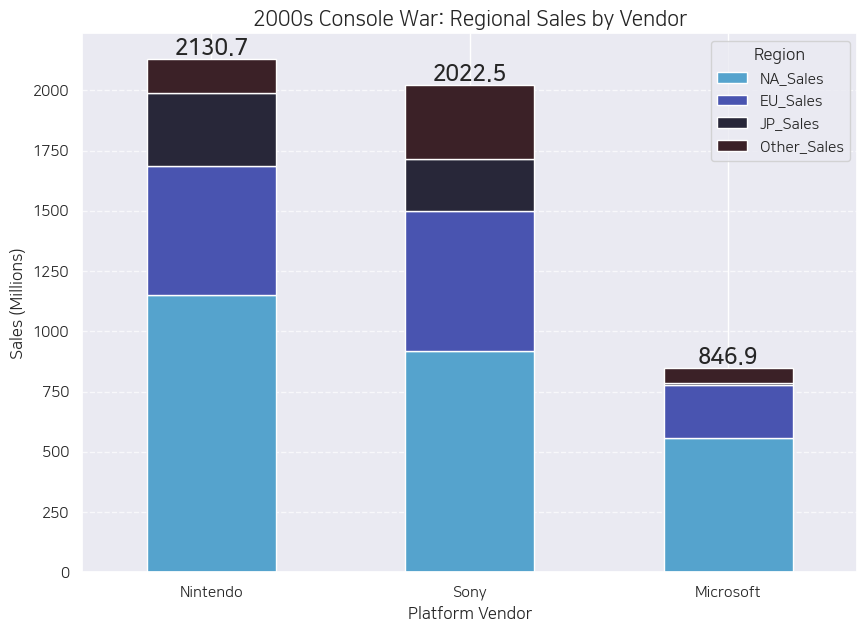

In [ ]:
# 1. 시각화할 데이터 정리 (Global_Sales 제외)
plot_df = df_2000s_region[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]

# 2. 그래프 그리기
ax = plot_df.plot(kind='bar', 
                    stacked=True,          # 누적 막대로 설정 (비중 확인 용이)
                    figsize=(10, 7), 
                    rot=0)                 # 글자 회전 방지

# 3. 그래프 꾸미기
plt.title('2000s Console War: Regional Sales by Vendor', fontsize=15)
plt.ylabel('Sales (Millions)', fontsize=12)
plt.xlabel('Platform Vendor', fontsize=12)
plt.legend(title='Region', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 합계 숫자 표시 (선택 사항)
for i, (idx, row) in enumerate(plot_df.iterrows()):
    total = row.sum()
    plt.text(i, total + 20, f'{total:.1f}', ha='center', fontweight='bold')

plt.show()

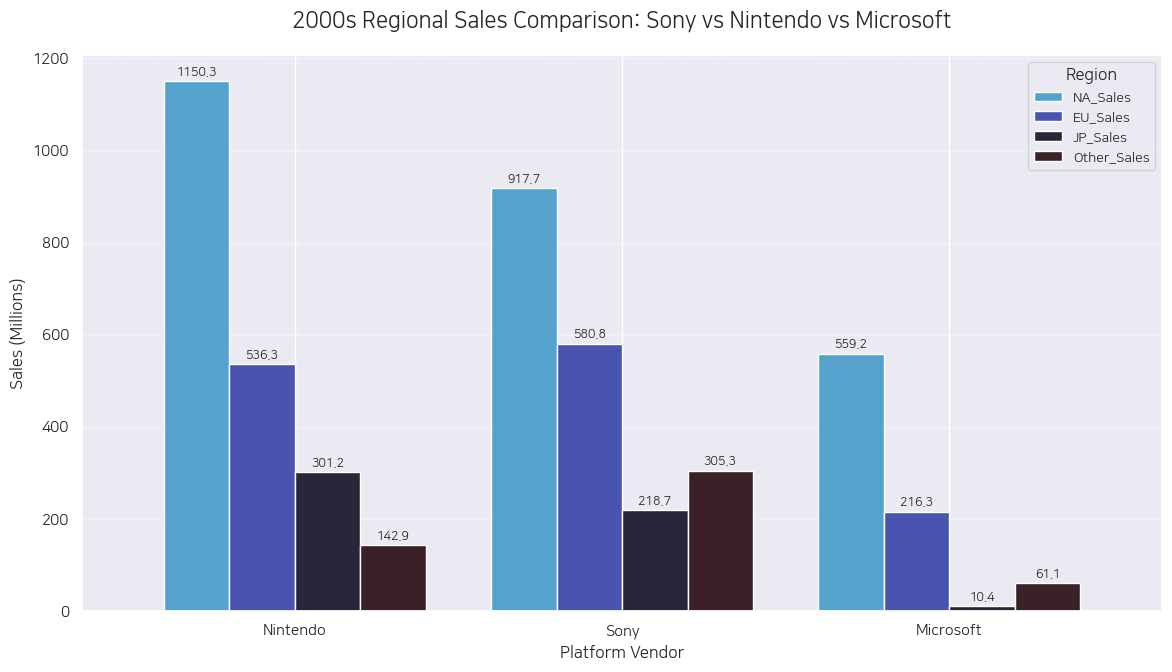

In [15]:
# 1. 그래프용 데이터 준비 (Global 제외)
plot_df = df_2000s_region[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]

# 2. 그래프 그리기
# 'stacked=False'가 핵심입니다 (기본값이 False라 생략 가능)
ax = plot_df.plot(kind='bar', 
                    figsize=(12, 7), 
                    width=0.8,      # 막대 두께 조절
                    rot=0)          # x축 이름(Nintendo 등) 똑바로

# 3. 디테일 설정
plt.title('2000s Regional Sales Comparison: Sony vs Nintendo vs Microsoft', fontsize=16, pad=20)
plt.ylabel('Sales (Millions)', fontsize=12)
plt.xlabel('Platform Vendor', fontsize=12)
plt.legend(title='Region', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 수치 표시 (가독성 업그레이드)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 7), 
                textcoords = 'offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# 다른 나라에서도 그럴까요?
# NA: 북미, EU: 유럽, JA: 일본, Other: 기타 
console_three = ['Nintendo','Sony','Microsoft']
video_df.query('Platform_Vendor in @console_three').groupby(['Platform_Vendor', 'Genre'], observed=False)[['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']].sum().sort_values(by=['Platform_Vendor','Genre', 'Global_Sales'], ascending=[True, True, False])

NA_Sales  EU_Sales  JP_Sales  Other_Sales  \
Platform_Vendor Genre                                                     
Microsoft       Action          195.18    101.09      3.15        26.23   
                Adventure        11.82      6.67      0.64         1.59   
                Fighting         36.17     12.18      1.33         3.82   
                Misc             75.06     24.35      0.46         8.47   
                Platform         13.06      7.18      0.03         1.53   
                Puzzle            0.94      0.12      0.15         0.07   
                Racing           58.52     38.73      0.74         8.17   
                Role-Playing     60.10     24.66      2.70         7.48   
                Shooter         252.16    107.11      3.50        30.80   
                Simulation       14.21      5.67      0.73         1.50   
                Sports          144.91     56.07      0.59        15.52   
                Strategy          8.80      3.35      0.13         1.00   
Nintendo        Action          272.78    114.80     64.35        27.84   
                Adventure        62.21     24.77     21.55         6.18   
                Fighting         65.44     20.30     35.43         4.83   
                Misc            233.02    122.82     79.59        31.86   
                Platform        312.37    122.61    119.10        26.81   
                Puzzle           97.63     43.44     51.21         9.95   
                Racing          127.07     59.29     31.32        12.85   
                Role-Playing    143.92     71.36    210.22        17.69   
                Shooter          86.75     19.67     12.11         5.03   
                Simulation      116.22     57.49     39.54        16.75   
                Sports          234.20    123.87     71.18        32.26   
                Strategy         25.51      8.39     22.91         2.19   
Sony            Action          370.34    288.74     90.96       129.41   
                Adventure        27.91     24.70     23.63         8.36   
                Fighting        116.24     67.03     39.21        27.78   
                Misc             93.16     66.08     26.39        34.61   
                Platform         96.20     66.44      9.40        22.31   
                Puzzle           11.44      5.68      4.93         2.22   
                Racing          169.34    136.53     21.33        55.56   
                Role-Playing    106.05     66.64    133.37        29.42   
                Shooter         200.62    162.71     18.05        62.19   
                Simulation       32.52     22.83     21.76         8.77   
                Sports          295.84    186.18     59.38        85.45   
                Strategy         14.94     11.32     22.65         4.20   

                              Global_Sales  
Platform_Vendor Genre                       
Microsoft       Action              325.74  
                Adventure            20.80  
                Fighting             53.50  
                Misc                108.40  
                Platform             21.86  
                Puzzle                1.27  
                Racing              106.28  
                Role-Playing         94.97  
                Shooter             393.71  
                Simulation           22.10  
                Sports              217.36  
                Strategy             13.29  
Nintendo        Action              480.44  
                Adventure           114.80  
                Fighting            126.09  
                Misc                467.66  
                Platform            581.09  
                Puzzle              202.74  
                Racing              230.78  
                Role-Playing        443.29  
                Shooter             123.82  
                Simulation          230.16  
                Sports              461.88  
                Strategy             59.08  
Sony     

In [17]:
# 글로벌 판매량 기준으로 장르별 실적 비교
genre_pivot = (video_df.query('Platform_Vendor in @console_three')
                .groupby(['Platform_Vendor', 'Genre'], observed=False)['Global_Sales']
                .sum()
                .unstack())

# 가독성을 위해 배경색 입히기 (주피터 노트북 환경)
genre_pivot.style.format("{:.3f}").background_gradient(cmap='coolwarm', axis=1)

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Platform_Vendor,,,,,,,,,,,,
Microsoft,325.740,20.800,53.500,108.400,21.860,1.270,106.280,94.970,393.710,22.100,217.360,13.290
Nintendo,480.440,114.800,126.090,467.660,581.090,202.740,230.780,443.290,123.820,230.160,461.880,59.080
Sony,879.480,84.600,250.140,220.430,194.370,24.320,382.630,335.310,443.580,85.910,626.580,53.100


In [18]:
# 각 벤더별로 글로벌 판매량 상위 3개 장르만 추출
top3_genres = (video_df.query('Platform_Vendor in @console_three')
                .groupby(['Platform_Vendor', 'Genre'], observed=False)['Global_Sales']
                .sum()
                .groupby(level=0)
                .nlargest(3)
                .reset_index(level=0, drop=True))

print("--- 제조사별 주력 장르 TOP 3 ---")
print(top3_genres)

--- 제조사별 주력 장르 TOP 3 ---
Platform_Vendor  Genre   
Microsoft        Shooter     393.71
                 Action      325.74
                 Sports      217.36
Nintendo         Platform    581.09
                 Action      480.44
                 Misc        467.66
Sony             Action      879.48
                 Sports      626.58
                 Shooter     443.58
Name: Global_Sales, dtype: float64


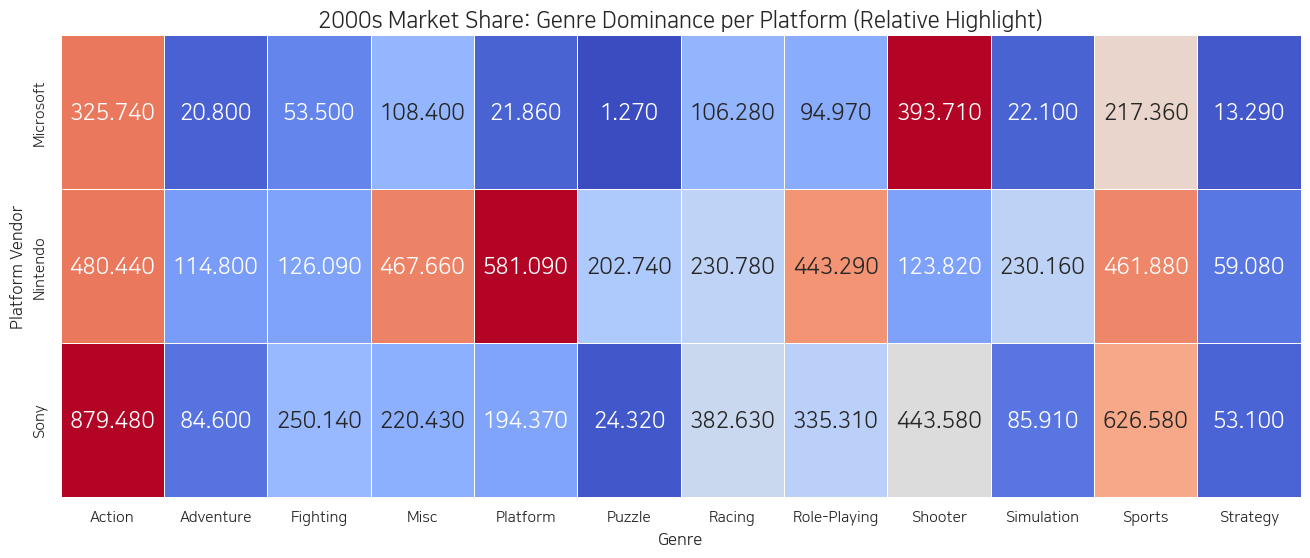

In [19]:
# 1. 행별로 정규화 (각 행의 최대값을 1로 만듦)
# 이렇게 해야 플랫폼 간의 체급 차이와 상관없이 각 플랫폼 내 '최애 장르'가 강조됩니다.
genre_pivot_norm = genre_pivot.div(genre_pivot.max(axis=1), axis=0)

plt.figure(figsize=(16, 6))

# 2. 히트맵 그리기
# data는 정규화된 것을 쓰되, annot(숫자 표시)는 원본(genre_pivot)을 넣는 것이 핵심입니다!
sns.heatmap(genre_pivot_norm, 
            annot=genre_pivot,      # 실제 판매량 숫자를 표시
            fmt=".3f",              # 요청하신 소수점 3자리
            cmap="coolwarm",          
            linewidths=.5,
            cbar=False)             # 정규화된 값의 색상바는 오해를 줄 수 있어 숨김

plt.title('2000s Market Share: Genre Dominance per Platform (Relative Highlight)', fontsize=16)
plt.ylabel('Platform Vendor', fontsize=12)
plt.xlabel('Genre', fontsize=12)

plt.show()

# 시대를 풍자한 게임들

## 1. 각 기종이 시대를 풍자한 시기

In [20]:
# 이제 그룹바이 기준이 연도로 바뀌게 된다. 단, 연도가 0으로 된 것은 빼고. (발매 취소된 겜이라... )
video_df_cp = video_df.copy()
video_df_cp.drop(video_df_cp[video_df_cp['Year'] == 0].index, inplace=True)
video_df_cp['Era'] = video_df_cp['Era'].cat.remove_unused_categories()

video_df_cp.groupby(['Era', 'Platform'], observed=False)['Name'].count().reset_index(name='Game_Count')

,Era,Platform,Game_Count
0,Pre-1980,2600,24
1,Pre-1980,3DO,0
2,Pre-1980,3DS,0
3,Pre-1980,DC,0
4,Pre-1980,DS,0
...,...,...,...
150,2010s,Wii,205
151,2010s,WiiU,143
152,2010s,X360,513
153,2010s,XB,0


In [21]:
platform_pivot = video_df_cp.pivot_table(index='Era', columns='Platform', values='Global_Sales', aggfunc='sum', observed=False)

# 0값을 제외하고 유의미한 데이터만 강조해서 보기
platform_pivot_cleaned = platform_pivot.loc[:, (platform_pivot.sum() > 0)]

# 행(Era)별로 가장 높은 매출을 기록한 플랫폼에 색깔 넣기
platform_pivot_cleaned.style.format("{:.3f}").background_gradient(cmap='coolwarm', axis=1)

Platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,N64,NES,NG,PC,PCFX,PS,PS2,PS3,PS4,PSP,PSV,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Era,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Pre-1980,21.210,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1980s,75.660,0.000,0.000,0.000,0.020,71.300,0.030,0.000,2.600,0.000,0.000,239.260,0.000,0.060,0.000,0.000,0.170,0.170,0.000,0.000,0.000,0.000,0.000,26.160,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1990s,0.210,0.100,0.000,14.550,0.000,174.910,0.150,0.070,25.760,0.040,215.540,11.810,1.440,54.700,0.030,686.060,39.110,0.000,0.000,0.000,0.000,33.590,1.870,173.890,0.160,1.140,0.000,0.000,0.000,0.990,0.000
2000s,0.000,0.000,0.310,1.420,779.410,9.240,318.320,199.290,0.000,0.000,3.340,0.000,0.000,106.670,0.000,44.600,1214.940,496.240,0.000,266.480,0.000,0.000,0.000,0.000,0.000,0.280,823.460,0.000,590.350,257.270,0.000
2010s,0.000,0.000,247.150,0.000,43.060,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,97.390,0.000,0.000,1.420,461.430,278.100,29.800,61.930,0.000,0.000,0.000,0.000,0.000,103.250,81.860,389.600,0.000,141.060


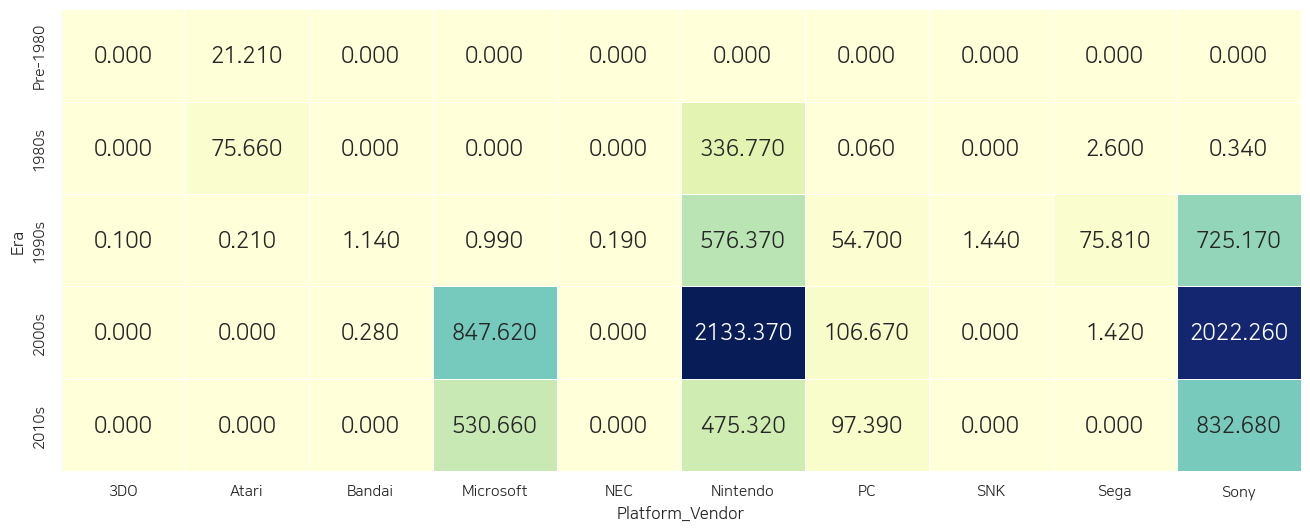

In [29]:
platform_pivot = video_df_cp.pivot_table(index='Era', columns='Platform_Vendor', values='Global_Sales', aggfunc='sum', observed=False)

# 0값을 제외하고 유의미한 데이터만 강조해서 보기
platform_pivot_cleaned = platform_pivot.loc[:, (platform_pivot.sum() > 0)]

# 행(Era)별로 가장 높은 매출을 기록한 플랫폼에 색깔 넣기
platform_pivot_cleaned.style.format("{:.3f}").background_gradient(cmap='coolwarm', axis=1)

plt.figure(figsize=(16, 6))

sns.heatmap(platform_pivot_cleaned, 
            annot=platform_pivot_cleaned,      # 실제 판매량 숫자를 표시
            fmt=".3f",              # 요청하신 소수점 3자리
            cmap="YlGnBu",          
            linewidths=.5,
            cbar=False)             # 정규화된 값의 색상바는 오해를 줄 수 있어 숨김

plt.show()

## 2. 각 플랫폼별로 일짱은 누구? 

In [30]:
# 1. 각 플랫폼별 Global_Sales가 가장 높은 행의 인덱스 추출
idx = video_df.groupby('Platform')['Global_Sales'].idxmax()

# 2. 해당 인덱스의 데이터만 추출하여 정리
top_titles = video_df.loc[idx, ['Platform_Vendor', 'Platform', 'Name', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]

# 3. 제조사(Vendor)와 플랫폼별로 보기 좋게 정렬
top_titles = top_titles.sort_values(['Platform_Vendor', 'Global_Sales'], ascending=[True, False])

# 소수점 3자리 설정 및 출력
top_titles.style.format({
    'NA_Sales': '{:.3f}', 'EU_Sales': '{:.3f}', 
    'JP_Sales': '{:.3f}', 'Other_Sales': '{:.3f}', 'Global_Sales': '{:.3f}'
}).background_gradient(cmap='coolwarm', subset=['Global_Sales'])

,Platform_Vendor,Platform,Name,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
12635,3DO,3DO,Policenauts,0.000,0.000,0.060,0.000,0.060
89,Atari,2600,Pac-Man,7.280,0.450,0.000,0.080,7.810
3931,Bandai,WS,Final Fantasy,0.000,0.000,0.510,0.000,0.510
15,Microsoft,X360,Kinect Adventures!,14.970,4.940,0.240,1.670,21.820
79,Microsoft,XB,Halo 2,6.820,1.530,0.050,0.080,8.490
101,Microsoft,XOne,Call of Duty: Black Ops 3,4.520,2.090,0.010,0.670,7.300
9223,NEC,TG16,Doukyuusei,0.000,0.000,0.140,0.000,0.140
14556,NEC,PCFX,Blue Breaker: Ken Yorimo Hohoemi o,0.000,0.000,0.030,0.000,0.030
0,Nintendo,Wii,Wii Sports,41.490,29.020,3.770,8.460,82.740
1,Nintendo,NES,Super Mario Bros.,29.080,3.580,6.810,0.770,40.240


In [31]:
# 1. 각 플랫폼별 매출 1위 게임 추출
top_idx = video_df_cp.groupby('Platform')['Global_Sales'].idxmax()
platform_tops = video_df_cp.loc[top_idx, ['Platform', 'Name', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]

# 2. 보기 편하게 판매량 순으로 정렬 (상위 15개 기종)
platform_tops = platform_tops.sort_values('Global_Sales', ascending=False).head(15)

# 3. 소수점 3자리 조절 및 스타일링
platform_tops.style.format("{:.3f}", subset=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'])\
                    .background_gradient(cmap='coolwarm', subset=['Global_Sales'])\
                    .bar(subset=['NA_Sales', 'EU_Sales', 'JP_Sales'], color='#FFA07A')\
                    .bar(subset=['Other_Sales'], color='#FFD700')

,Platform,Name,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii,Wii Sports,41.490,29.020,3.770,8.460,82.740
1,NES,Super Mario Bros.,29.080,3.580,6.810,0.770,40.240
4,GB,Pokemon Red/Pokemon Blue,11.270,8.890,10.220,1.000,31.370
6,DS,New Super Mario Bros.,11.380,9.230,6.500,2.900,30.010
15,X360,Kinect Adventures!,14.970,4.940,0.240,1.670,21.820
16,PS3,Grand Theft Auto V,7.010,9.270,0.970,4.140,21.400
17,PS2,Grand Theft Auto: San Andreas,9.430,0.400,0.410,10.570,20.810
18,SNES,Super Mario World,12.780,3.750,3.540,0.550,20.610
25,GBA,Pokemon Ruby/Pokemon Sapphire,6.060,3.900,5.380,0.500,15.850
32,3DS,Pokemon X/Pokemon Y,5.170,4.050,4.340,0.790,14.350


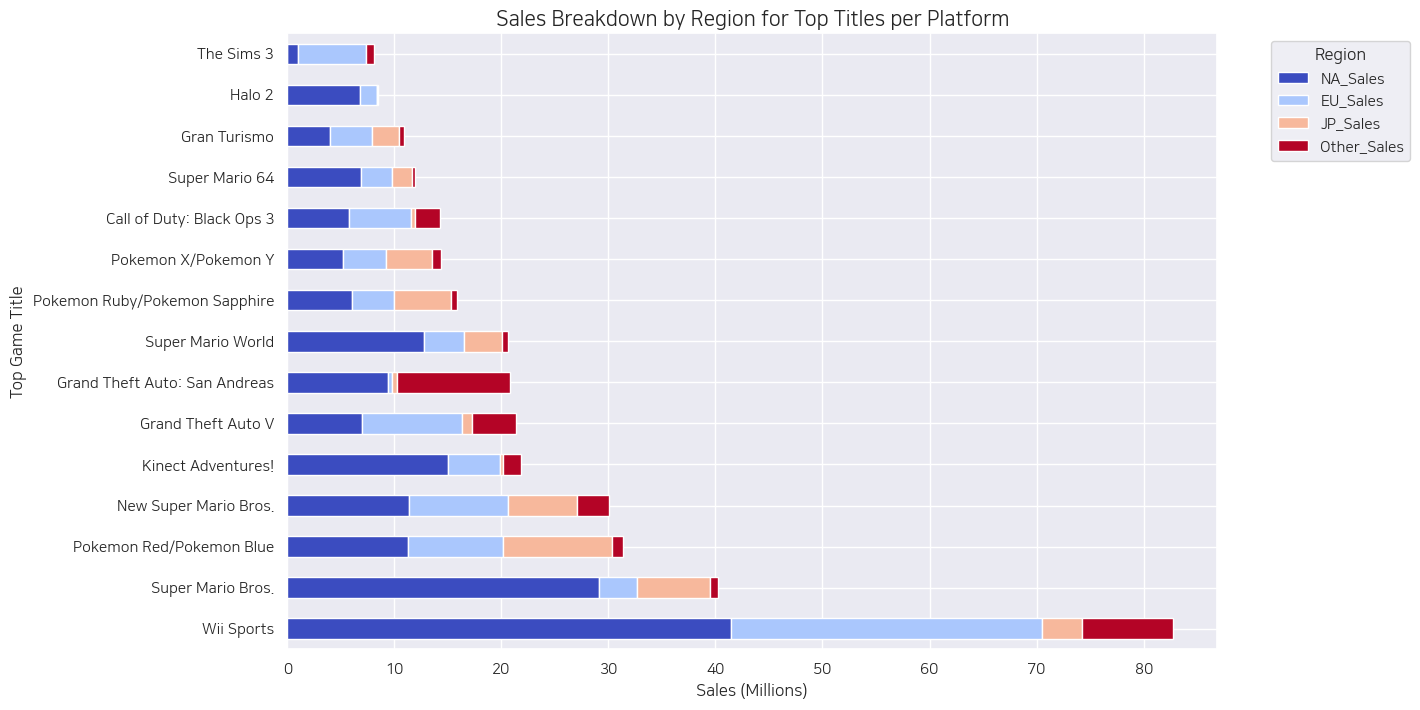

In [32]:
# 시각화를 위해 게임 이름을 인덱스로 설정
plot_data = platform_tops.set_index('Name')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]

# 누적 막대 그래프 그리기
plot_data.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='coolwarm')
plt.title('Sales Breakdown by Region for Top Titles per Platform', fontsize=15)
plt.xlabel('Sales (Millions)')
plt.ylabel('Top Game Title')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [33]:
# 1. Vendor와 Era별로 Global_Sales가 최대인 행의 인덱스를 추출
# observed=True를 써서 데이터가 없는 Unknown 시대는 제외합니다.
top_idx_era = video_df_cp.groupby(['Platform_Vendor', 'Era'], observed=True)['Global_Sales'].idxmax()

# 2. 해당 인덱스로 데이터프레임 생성
era_champions = video_df_cp.loc[top_idx_era, 
                                ['Platform_Vendor', 'Era', 'Platform', 'Name', 'NA_Sales', 'JP_Sales', 'Global_Sales']]

# 3. 가독성을 위해 정렬
era_champions = era_champions.sort_values(['Platform_Vendor', 'Era'])

# 4. 소수점 3자리와 스타일 적용
era_champions.style.format("{:.3f}", subset=['NA_Sales', 'JP_Sales', 'Global_Sales'])\
                    .background_gradient(cmap='coolwarm', subset=['Global_Sales'])

,Platform_Vendor,Era,Platform,Name,NA_Sales,JP_Sales,Global_Sales
12635,3DO,1990s,3DO,Policenauts,0.000,0.060,0.060
258,Atari,Pre-1980,2600,Asteroids,4.000,0.000,4.310
89,Atari,1980s,2600,Pac-Man,7.280,0.000,7.810
7369,Atari,1990s,2600,Ghostbusters II,0.200,0.000,0.210
3931,Bandai,1990s,WS,Final Fantasy,0.000,0.510,0.510
6669,Bandai,2000s,WS,Final Fantasy II,0.000,0.250,0.250
2083,Microsoft,1990s,XB,NFL Fever 2002,0.740,0.000,0.990
15,Microsoft,2000s,X360,Kinect Adventures!,14.970,0.240,21.820
23,Microsoft,2010s,X360,Grand Theft Auto V,9.630,0.060,16.380
9223,NEC,1990s,TG16,Doukyuusei,0.000,0.140,0.140


In [42]:
# 1. 진영별 전체 매출 합계
vendor_total = video_df_cp.groupby('Platform_Vendor')['Global_Sales'].sum()

# 2. 진영별 상위 10개 게임의 매출 합계
top10_sum = (video_df_cp.sort_values('Global_Sales', ascending=False)
                .groupby('Platform_Vendor')
                .head(10)
                .groupby('Platform_Vendor')['Global_Sales'].sum())

# 3. 비중 계산 (단위: %)
dependency_df = pd.DataFrame({
    'Total_Sales': vendor_total,
    'Top10_Sales': top10_sum,
    'Dependency_Rate(%)': (top10_sum / vendor_total) * 100
}).sort_values('Dependency_Rate(%)', ascending=False)

dependency_df.style.format("{:.3f}")

,Total_Sales,Top10_Sales,Dependency_Rate(%)
Platform_Vendor,,,
3DO,0.100,0.100,100.000
Bandai,1.420,1.420,100.000
NEC,0.190,0.190,100.000
SNK,1.440,1.390,96.528
Sega,79.830,27.430,34.361
Atari,97.080,31.500,32.447
PC,258.820,49.600,19.164
Nintendo,3521.830,369.390,10.489
Microsoft,1379.270,138.090,10.012


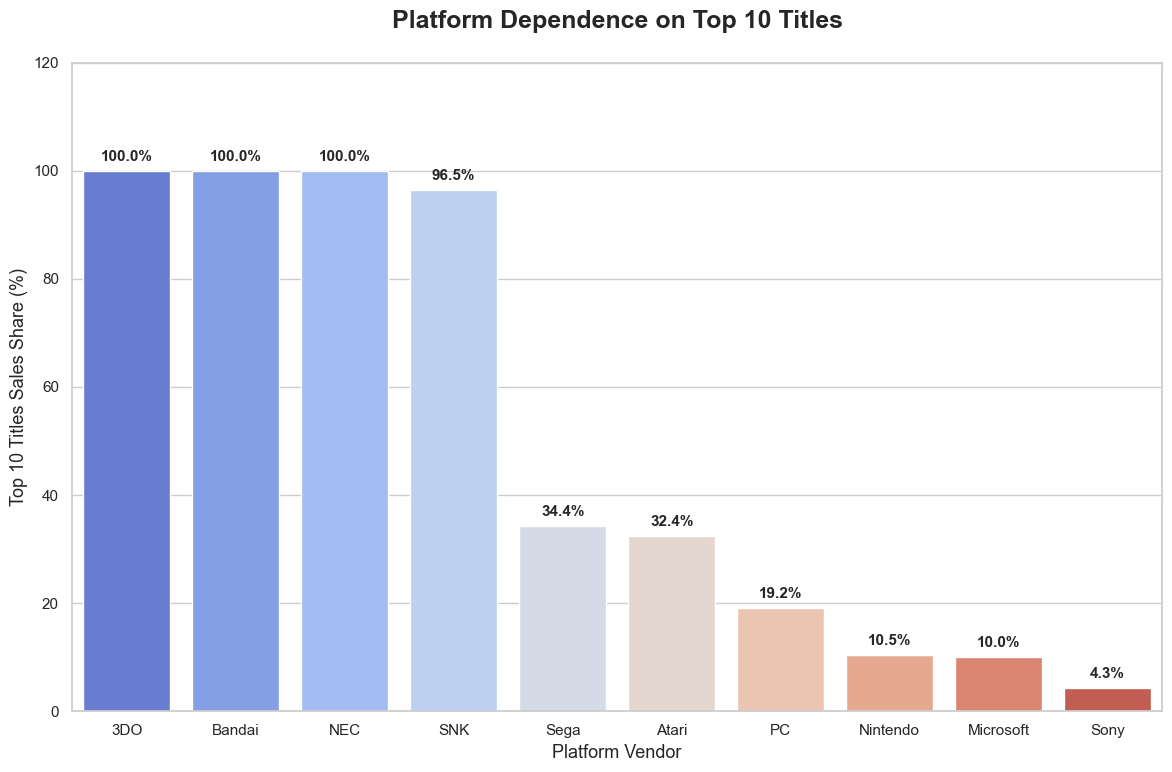

In [ ]:
# 데이터 정렬 (이미 되어있지만 확인 차원)
plot_df = dependency_df.reset_index()

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 1. 의존도(%) 막대 그래프 생성
ax = sns.barplot(data=plot_df, x='Platform_Vendor', y='Dependency_Rate(%)', 
                palette='coolwarm', hue = 'Platform_Vendor')

# 2. 막대 위에 수치 레이블 추가 (포폴용 디테일)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold', 
                xytext=(0, 5), textcoords='offset points')

# 3. 그래프 꾸미기
plt.title('Platform Dependence on Top 10 Titles', fontsize=18, pad=25, fontweight='bold')
plt.xlabel('Platform Vendor', fontsize=13)
plt.ylabel('Top 10 Titles Sales Share (%)', fontsize=13)
plt.ylim(0, plot_df['Dependency_Rate(%)'].max() * 1.2) # 상단 여백 확보
plt.rc('font', family='NanumSquare_ac')

# 4. 보조 설명 추가 (인사이트 강조)
plt.text(0.5, -0.15, "* Higher percentage indicates a 'Winner-Take-All' market structure for that vendor.", 
            transform=ax.transAxes, ha='center', fontsize=10, color='gray', style='italic')

plt.tight_layout()
plt.show()

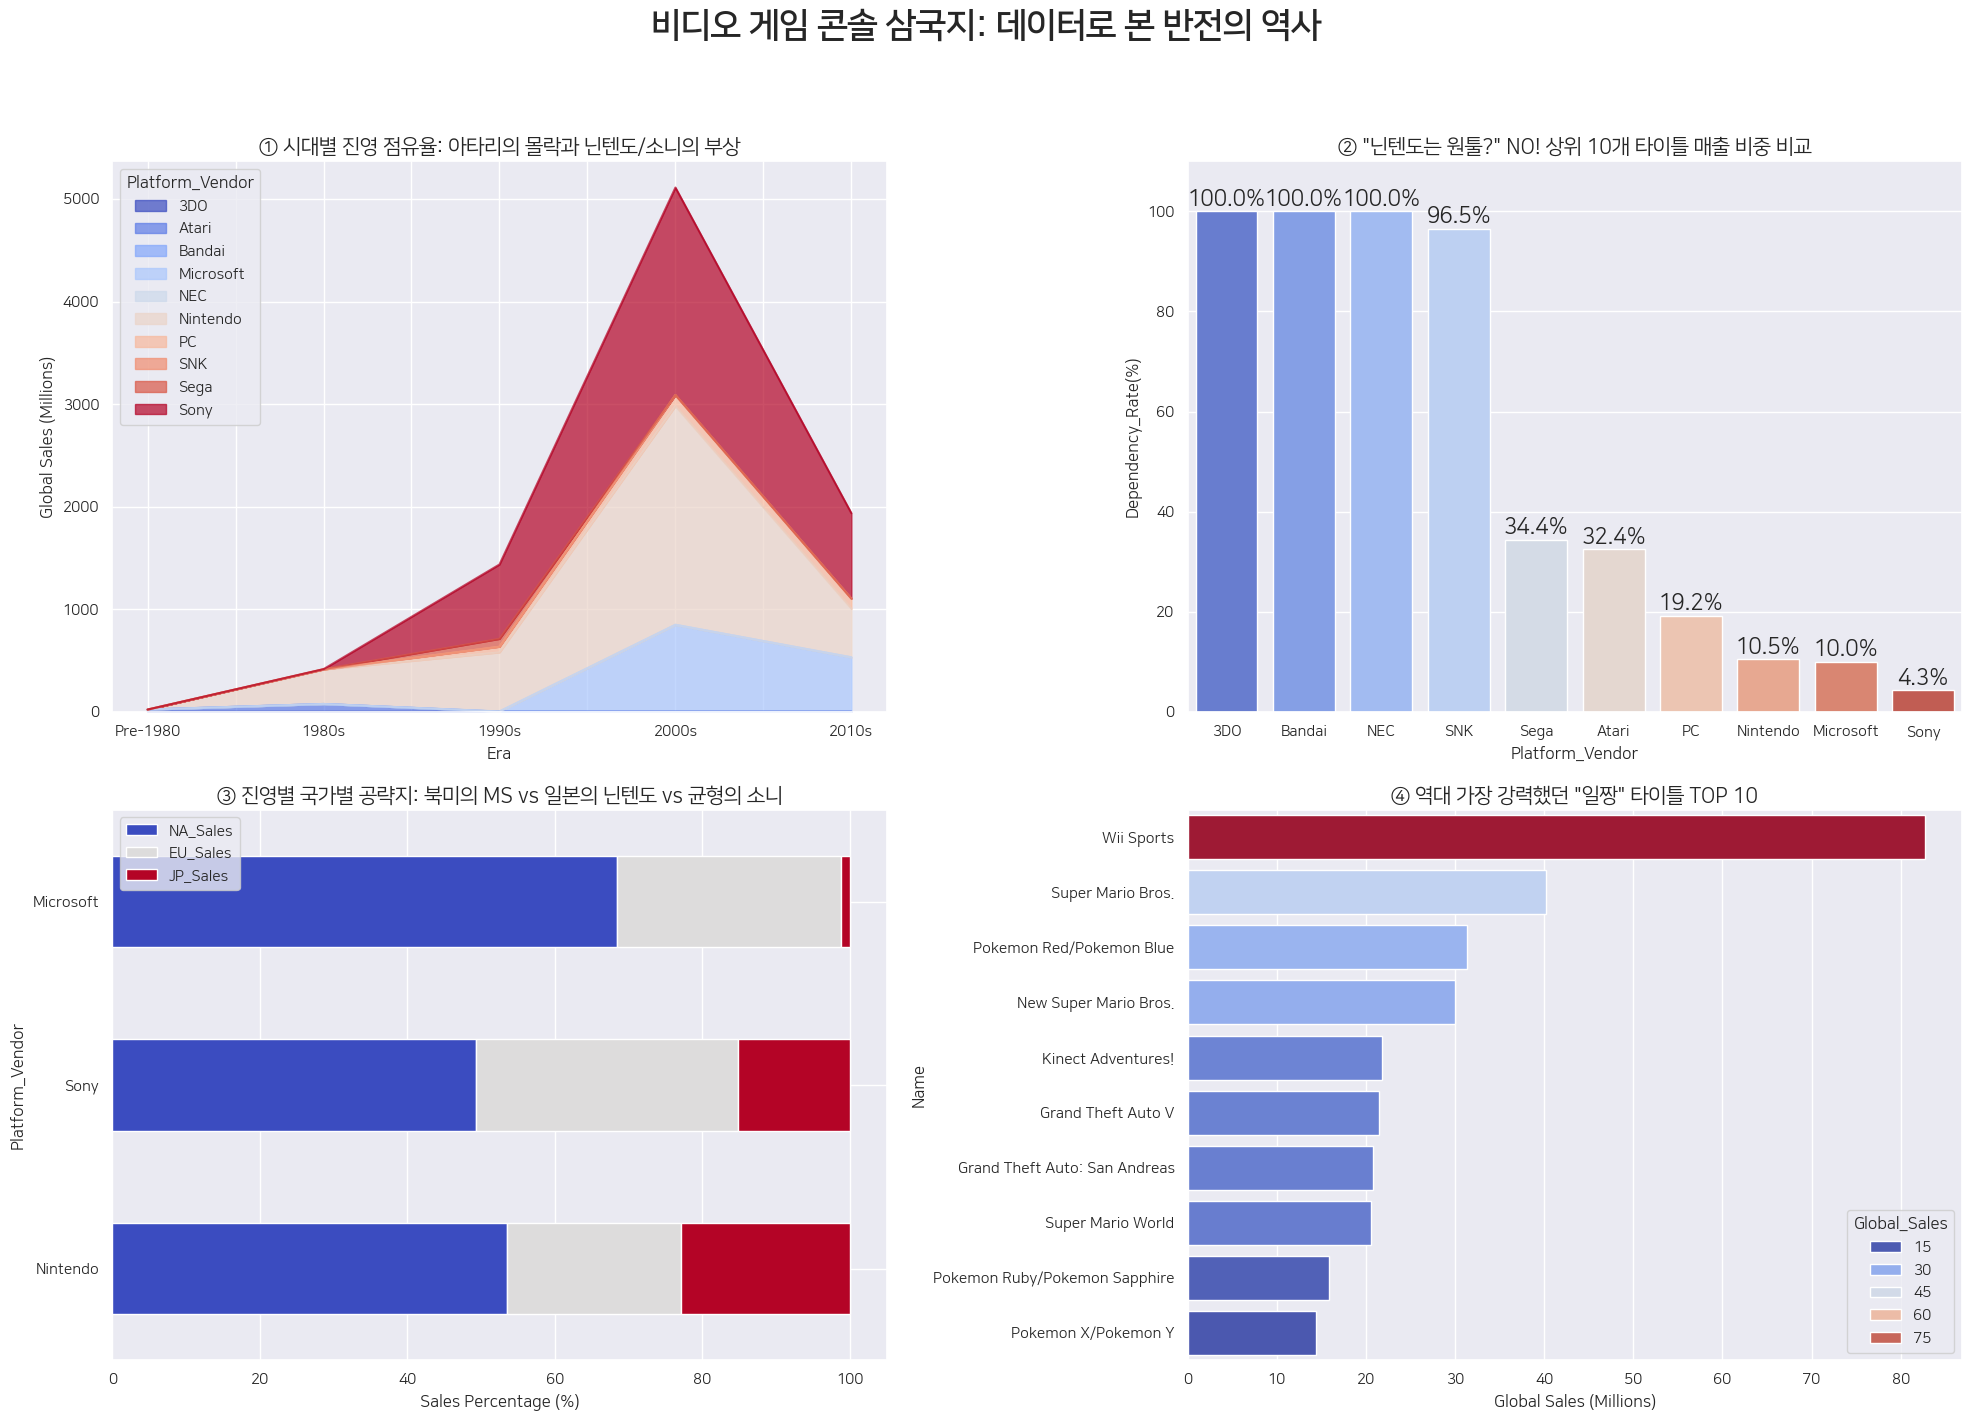

In [35]:
# 시각화를 위한 통합 대시보드 설정
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('비디오 게임 콘솔 삼국지: 데이터로 본 반전의 역사', fontsize=25, fontweight='bold')

# 1. [좌상단] 시대별 플랫폼 제조사 매출 추이 (The History)
era_revenue = video_df_cp.groupby(['Era', 'Platform_Vendor'], observed=True)['Global_Sales'].sum().unstack().fillna(0)
era_revenue.plot(kind='area', stacked=True, ax=axes[0, 0], alpha=0.7, cmap='coolwarm')
axes[0, 0].set_title('① 시대별 진영 점유율: 아타리의 몰락과 닌텐도/소니의 부상', fontsize=15)
axes[0, 0].set_ylabel('Global Sales (Millions)')

# 2. [우상단] TOP 10 의존도 비교 (The Myth Buster)
sns.barplot(x=dependency_df.index, y='Dependency_Rate(%)', data=dependency_df, hue = dependency_df.index, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('② "닌텐도는 원툴?" NO! 상위 10개 타이틀 매출 비중 비교', fontsize=15)
axes[0, 1].set_ylim(0, 110) # 3DO 등 소규모 벤더 제외하고 주요 3사 강조를 위해 조정 가능
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# 3. [좌하단] 주요 진영별 국가별 판매 비중 (Region Strategy)
vendor_region = video_df_cp.groupby('Platform_Vendor')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()
vendor_region_pct = vendor_region.div(vendor_region.sum(axis=1), axis=0) * 100
vendor_region_pct.loc[['Nintendo', 'Sony', 'Microsoft']].plot(kind='barh', stacked=True, ax=axes[1, 0], colormap='coolwarm')
axes[1, 0].set_title('③ 진영별 국가별 공략지: 북미의 MS vs 일본의 닌텐도 vs 균형의 소니', fontsize=15)
axes[1, 0].set_xlabel('Sales Percentage (%)')

# 4. [우하단] 플랫폼별 일짱 게임의 위엄 (The Champions)
sns.barplot(x='Global_Sales', y='Name', data=platform_tops.head(10), hue='Global_Sales', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('④ 역대 가장 강력했던 "일짱" 타이틀 TOP 10', fontsize=15)
axes[1, 1].set_xlabel('Global Sales (Millions)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()